**1: Preparação do Ambiente**

In [23]:
# Célula 1: Setup do Ambiente de Avaliação e Produção
from google.colab import drive
drive.mount('/content/drive')

# 1. Ignoramos o aviso de remoção do wandb
!pip uninstall -y wandb

# 2. Atualizamos o torchao para o carregamento do LoRA
!pip install -q -U torchao

# 3. A Engrenagem: versão 8.1.8 que compatível com o Google Colab e o gTTS
!pip install -q click==8.1.8

# 4. Instalamos o nosso Stack Multimodal
!pip install -q diffusers transformers accelerate torchmetrics[image] gradio gTTS huggingface_hub peft

print("✅ Ambiente de produção preparado com sucesso!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Found existing installation: wandb 0.28.0
Uninstalling wandb-0.28.0:
  Successfully uninstalled wandb-0.28.0
✅ Ambiente de produção preparado com sucesso!


**2: (Etapa 3) — Avaliação Matemática (CLIPScore)**

Carregando o Modelo Base (SD 1.5)...


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Carregando o Modelo Ajustado (LoRA)...


...

Carregando o Avaliador Matemático (CLIP)...


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]


🎨 Gerando imagens para avaliação com o prompt:
'estilo_pixel_art, Cena em pixel art de uma estrada de acesso para uma lagoa, com muitas flores vermelhas no caminho.'



  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

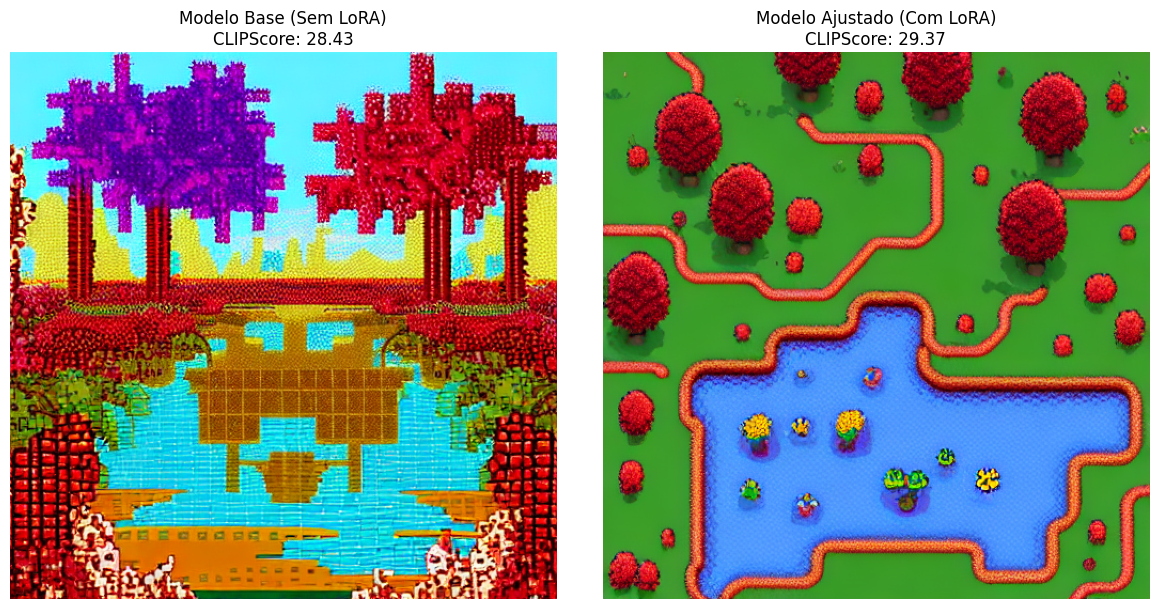

In [24]:
# Célula 2: Cálculo do CLIPScore e Teste A/B Visual
import torch
import matplotlib.pyplot as plt
import torch.nn.functional as F
from diffusers import StableDiffusionPipeline
from transformers import CLIPProcessor, CLIPModel

device = "cuda" if torch.cuda.is_available() else "cpu"

# 1. Carregamento dos Modelos de Difusão (Base e LoRA)
print("Carregando o Modelo Base (SD 1.5)...")
pipe_base = StableDiffusionPipeline.from_pretrained("runwayml/stable-diffusion-v1-5", torch_dtype=torch.float16).to(device)

print("Carregando o Modelo Ajustado (LoRA)...")
pipe_lora = StableDiffusionPipeline.from_pretrained("runwayml/stable-diffusion-v1-5", torch_dtype=torch.float16).to(device)
caminho_lora = "/content/drive/MyDrive/Atelie_Generativo_LoRA/PixelArt_Rank32"
pipe_lora.load_lora_weights(caminho_lora)

# 2. Carregamento Explícito do Avaliador CLIP
print("Carregando o Avaliador Matemático (CLIP)...")
clip_id = "openai/clip-vit-base-patch16"
processor = CLIPProcessor.from_pretrained(clip_id)
clip_model = CLIPModel.from_pretrained(clip_id).to(device)

# 3. Geração das Imagens (Teste A/B)
prompt_avaliacao = "estilo_pixel_art, Cena em pixel art de uma estrada de acesso para uma lagoa, com muitas flores vermelhas no caminho."
print(f"\n🎨 Gerando imagens para avaliação com o prompt:\n'{prompt_avaliacao}'\n")

gerador_seed = torch.manual_seed(42) # Seed fixa para o teste ser justo
img_base = pipe_base(prompt_avaliacao, num_inference_steps=30, generator=gerador_seed).images[0]
img_lora = pipe_lora(prompt_avaliacao, num_inference_steps=30, generator=gerador_seed).images[0]

# 4. Implementação Matemática do CLIPScore (Similaridade de Cossenos)
def calcular_clip_score_robusto(imagem, texto):
    # Transforma a imagem e o texto em tensores compreensíveis pelo CLIP
    inputs = processor(text=[texto], images=imagem, return_tensors="pt", padding=True)
    inputs = {k: v.to(device) for k, v in inputs.items()} # Envia para a GPU

    with torch.no_grad():
        # Passa pelo modelo
        outputs = clip_model(**inputs)
        # Extrai os vetores matemáticos puros (Embeddings)
        image_embeds = outputs.image_embeds
        text_embeds = outputs.text_embeds

    # Calcula a distância entre os vetores (Cosseno) e multiplica por 100 (Padrão da métrica)
    cosine_sim = F.cosine_similarity(image_embeds, text_embeds)
    return (cosine_sim.item() * 100)

# Calculando...
score_base = calcular_clip_score_robusto(img_base, prompt_avaliacao)
score_lora = calcular_clip_score_robusto(img_lora, prompt_avaliacao)

# 5. Exibição do Relatório Visual
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(img_base)
axes[0].set_title(f"Modelo Base (Sem LoRA)\nCLIPScore: {score_base:.2f}")
axes[0].axis("off")

axes[1].imshow(img_lora)
axes[1].set_title(f"Modelo Ajustado (Com LoRA)\nCLIPScore: {score_lora:.2f}")
axes[1].axis("off")

plt.tight_layout()
plt.show()

👨‍🏫 Avaliação Humana e Overfitting:
> Overfitting: O modelo decorou os dados ou aprendeu o estilo? Analisem a imagem gerada pelo LoRA. Se ela for idêntica a uma das fotos do dataset, houve memorização (overfitting). Se for uma cena nova, mas com a "vibe" do Pixel Art, houve generalização bem-sucedida!



**3: O "Shift" para Cloud (Subindo o modelo para o Hugging Face Hub)**

In [25]:
# Célula 3: Publicação do Modelo (Weights) no Hugging Face Hub
from huggingface_hub import HfApi, login

print("🔑 Faça o login com o seu Token de ESCRITA (Write Token) do Hugging Face:")
login() # Um prompt aparecerá para você colar o token (não escreva no código!)

# Substitua pelas suas credenciais
SEU_USUARIO_HF = "roderiok" # Coloque seu usuário real aqui
NOME_DO_MODELO = "pixelart-16bit-lora"

api = HfApi()
repo_id = f"{SEU_USUARIO_HF}/{NOME_DO_MODELO}"

print(f"🚀 Criando repositório público: {repo_id}...")
api.create_repo(repo_id=repo_id, exist_ok=True)

print("⏳ Enviando os pesos do LoRA. Isso pode levar alguns minutos...")
api.upload_folder(
    folder_path=caminho_lora, # A pasta do Drive com o rank32
    repo_id=repo_id,
    repo_type="model"
)
print("✅ LoRA publicado com sucesso no Hugging Face Hub!")

🔑 Faça o login com o seu Token de ESCRITA (Write Token) do Hugging Face:
🚀 Criando repositório público: roderiok/pixelart-16bit-lora...
⏳ Enviando os pesos do LoRA. Isso pode levar alguns minutos...


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...6464.6167c298e010.19586.1: 100%|##########| 2.35kB / 2.35kB            

  ..._lora_weights.safetensors:  31%|###1      | 7.98MB / 25.5MB            

...

  ...kpoint-1500/scheduler.bin: 100%|##########| 1.40kB / 1.40kB            

  ...checkpoint-1000/scaler.pt: 100%|##########| 1.38kB / 1.38kB            

  ..._lora_weights.safetensors: 100%|##########| 25.5MB / 25.5MB            

No files have been modified since last commit. Skipping to prevent empty commit.


✅ LoRA publicado com sucesso no Hugging Face Hub!


**4: (Etapa 4) — Desenvolvimento do Pipeline Multimodal Web**

In [26]:
# Célula 4: Construção da Estrutura do App (Infraestrutura as Code)
import os

app_dir = "/content/meu_app_espaco"
os.makedirs(app_dir, exist_ok=True)

# 1. Criação do requirements.txt
with open(os.path.join(app_dir, "requirements.txt"), "w") as f:
    f.write("gradio\ndiffusers\ntransformers\naccelerate\ntorch\ngTTS\npeft\n")

# 2. Criação do app.py (O Pipeline Multimodal)
app_code = """
import gradio as gr
import torch
from diffusers import StableDiffusionPipeline
from gtts import gTTS
from transformers import pipeline
import os

# Configuração: Usa GPU se disponível no Spaces (ex: ZeroGPU), senão cai para CPU (Inference via software)
device = "cuda" if torch.cuda.is_available() else "cpu"
torch_dtype = torch.float16 if torch.cuda.is_available() else torch.float32

# Obtém o modelo base dos pesos
print(f"Inicializando modelo no dispositivo {device}")
pipe = StableDiffusionPipeline.from_pretrained("runwayml/stable-diffusion-v1-5", torch_dtype=torch_dtype).to(device)

# Carrega o LoRA usando a Inference API
pipe.load_lora_weights("roderiok/pixelart-16bit-lora")

# Modelo para expandir o prompt do usuário com mais detalhes visuais
expansor_prompt = pipeline(
    "text-generation",
    model="Qwen/Qwen2.5-0.5B-Instruct",
    torch_dtype=torch_dtype,
    device=0 if device == "cuda" else -1,
)

NEGATIVE_PROMPT_PADRAO = "blurry, low quality, jpeg artifacts, photorealistic, 3d render, watermark, text, signature, deformed"

def expandir_prompt(prompt_usuario):
    mensagens = [
        {
            "role": "system",
            "content": (
                "Você é um assistente que melhora a descrição de prompts de descrições visuais. Seu objetivo é tornar eles mais ricos e detalhados para geração de imagens em pixel art. Responda apenas com o prompt melhorado, em uma única frase, sem explicações adicionais. Adicione detalhes de cores, iluminação, perspectiva e elementos visuais que possam enriquecer a cena, mantendo o estilo pixel art e o que foi solicitado pelo usuário."
            ),
        },
        {"role": "user", "content": prompt_usuario},
    ]
    resposta = expansor_prompt(mensagens, max_new_tokens=80, do_sample=True, temperature=0.7)
    return resposta[0]["generated_text"][-1]["content"].strip()

def gerar_experiencia_multimodal(prompt_usuario, negative_prompt, num_inference_steps, guidance_scale, lora_scale):

    # Modalidade 1: Orquestração do Texto (expande o prompt do usuário via LLM e prefixa o estilo do LoRA)
    prompt_expandido = expandir_prompt(prompt_usuario)
    prompt_orquestrado = f"estilo_pixel_art, {prompt_expandido}"

    # Modalidade 2: Visão Computacional (Geração da Imagem)
    imagem = pipe(
        prompt_orquestrado,
        negative_prompt=negative_prompt,
        num_inference_steps=num_inference_steps,
        guidance_scale=guidance_scale,
        cross_attention_kwargs={"scale": lora_scale},
    ).images[0]

    # Modalidade 3: Síntese de Áudio
    texto_narracao = f"Gerando arte em pixel art para a sua solicitação: {prompt_usuario}."
    tts = gTTS(texto_narracao, lang='pt')
    audio_path = "narracao.mp3"
    tts.save(audio_path)

    return prompt_orquestrado, imagem, audio_path

# Interface UI/UX
with gr.Blocks(theme=gr.Theme.from_hub("hmb/midnight")) as demo:
    gr.Markdown("# 👾 Ateliê Generativo: Multimodal Pixel Art (16-bits)")
    gr.Markdown("Transforme suas ideias em arte retrô narrada. Pipeline Integrado: Texto ➔ Imagem ➔ Áudio.")

    with gr.Row():
        with gr.Column(scale=1):
            entrada = gr.Textbox(label="O que você deseja criar?", placeholder="Ex: Cena em pixel art de um lago, árvores e um barco.")
            negative_prompt = gr.Textbox(label="Prompt Negativo", value=NEGATIVE_PROMPT_PADRAO)

            with gr.Accordion("Parâmetros de Inferência", open=False):
                num_inference_steps = gr.Slider(label="Passos de Inferência", minimum=1, maximum=100, value=30, step=1)
                guidance_scale = gr.Slider(label="Guidance Scale", minimum=1.0, maximum=20.0, value=7.5, step=0.5)
                lora_scale = gr.Slider(label="Intensidade do LoRA (Estilo Pixel Art)", minimum=0.0, maximum=1.0, value=0.7, step=0.05)

            btn = gr.Button("Sintetizar", variant="primary")

        with gr.Column(scale=2):
            with gr.Row():
                saida_prompt = gr.Textbox(label="Texto Orquestrado", interactive=False)
                saida_audio = gr.Audio(label="Voz do Sistema")

            saida_imagem = gr.Image(label="Arte Gerada!")

    btn.click(
        fn=gerar_experiencia_multimodal,
        inputs=[entrada, negative_prompt, num_inference_steps, guidance_scale, lora_scale],
        outputs=[saida_prompt, saida_imagem, saida_audio],
    )

demo.launch()
"""

with open(os.path.join(app_dir, "app.py"), "w", encoding="utf-8") as f:
    f.write(app_code)

print("✅ Arquivos atualizados com sucesso!")

✅ Arquivos atualizados com sucesso!


**5: Deploy Final no Hugging Face Spaces (O "Go Live")**

**⚠️ Gestão de Chaves e Segurança:**
> Como estamos submetendo via API e usando as variáveis nativas do Hugging Face, os tokens estão criptografados.



In [29]:
# Célula 5: Deploy da Aplicação no Hugging Face Spaces
from huggingface_hub import HfApi

api = HfApi()
repo_space_id = f"{SEU_USUARIO_HF}/atelie-multimodal-pixelart"

print(f"🚀 Criando o Servidor (Space) público: {repo_space_id}...")
# Criamos um Space com o SDK do Gradio
api.create_repo(repo_id=repo_space_id, repo_type="space", space_sdk="gradio", exist_ok=True)

print("⏳ Fazendo o Deploy dos arquivos da aplicação. Aguarde...")
api.upload_folder(
    folder_path=app_dir,
    repo_id=repo_space_id,
    repo_type="space"
)

print(f"🎉 DEPLOY CONCLUÍDO! Acesse sua aplicação web em: https://huggingface.co/spaces/{repo_space_id}")

⏳ Enviando arquivos para o Space já existente: roderiok/atelie-multimodal-pixelart...
🎉 DEPLOY CONCLUÍDO! Acesse sua aplicação em: https://huggingface.co/spaces/roderiok/atelie-multimodal-pixelart


🏆 Validação do Resultado

> Após executar a Célula 5, clique no link gerado e vá para a aba Files and versions no seu Space para conferir se o app.py está lá. O Space levará alguns minutos no estado Building (Construindo a imagem Docker). Assim que ficar Running, o seu pipeline multimodal estará acessível para avaliação!

